# Projekt: Predykcja ryzyka zawału serca

Celem projektu jest analiza zbioru danych medycznych oraz budowa modeli sztucznej inteligencji do przewidywania ryzyka wystąpienia zawału serca.
W projekcie wykorzystuję analizę eksploracyjną danych, porównanie modeli opisowych oraz implementację i strojenie modeli uczenia maszynowego.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

import joblib

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Wczytanie danych


In [2]:
df = pd.read_csv("heart_attack_prediction_dataset.csv")

print("Kształt zbioru:", df.shape)
display(df.head())

Kształt zbioru: (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
print("Kolumny:")
print(df.columns.tolist())

display(df.info())

display(df.isnull().sum().sort_values(ascending=False).head(20))

Kolumny:
['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk']
<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   str    
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   str    
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   str    
 5   Heart Rate                     

None

Patient ID                 0
Age                        0
Sex                        0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Diabetes                   0
Family History             0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Previous Heart Problems    0
Medication Use             0
Stress Level               0
Sedentary Hours Per Day    0
Income                     0
BMI                        0
Triglycerides              0
dtype: int64

## Przygotowanie danych
Kolumna `Blood Pressure` ma postać tekstową typu `160/88`, dlatego rozdzielamy ją na dwie cechy liczbowe.

In [ ]:
bp = df["Blood Pressure"].astype(str).str.split("/", expand=True)
df["BP_sys"] = pd.to_numeric(bp[0], errors="coerce")
df["BP_dia"] = pd.to_numeric(bp[1], errors="coerce")
df = df.drop(columns=["Blood Pressure"])

display(df.head())

,Patient ID,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,BP_sys,BP_dia
0,BMW7812,67,Male,208,72,0,0,1,0,0,...,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,158,88
1,CZE1114,21,Male,389,98,1,1,1,1,1,...,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0,165,93
2,BNI9906,21,Female,324,72,1,0,0,0,0,...,28.176571,587,4,4,France,Europe,Northern Hemisphere,0,174,99
3,JLN3497,84,Male,383,73,1,1,1,0,1,...,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,163,100
4,GFO8847,66,Male,318,93,1,1,1,1,0,...,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,91,88


In [ ]:
## Statystyki opisowe

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,8763.0,53.707977,21.249509,18.000000,35.000000,54.000000,72.000000,90.000000
Cholesterol,8763.0,259.877211,80.863276,120.000000,192.000000,259.000000,330.000000,400.000000
Heart Rate,8763.0,75.021682,20.550948,40.000000,57.000000,75.000000,93.000000,110.000000
Diabetes,8763.0,0.652288,0.476271,0.000000,0.000000,1.000000,1.000000,1.000000
Family History,8763.0,0.492982,0.499979,0.000000,0.000000,0.000000,1.000000,1.000000
Smoking,8763.0,0.896839,0.304186,0.000000,1.000000,1.000000,1.000000,1.000000
Obesity,8763.0,0.501426,0.500026,0.000000,0.000000,1.000000,1.000000,1.000000
Alcohol Consumption,8763.0,0.598083,0.490313,0.000000,0.000000,1.000000,1.000000,1.000000
Exercise Hours Per Week,8763.0,10.014284,5.783745,0.002442,4.981579,10.069559,15.050018,19.998709
Previous Heart Problems,8763.0,0.495835,0.500011,0.000000,0.000000,0.000000,1.000000,1.000000


## Analiza rozkładu klas i cech

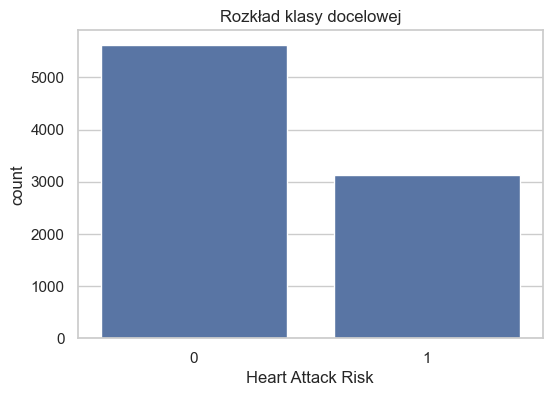

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Heart Attack Risk", data=df)
plt.title("Rozkład klasy docelowej")
plt.show()

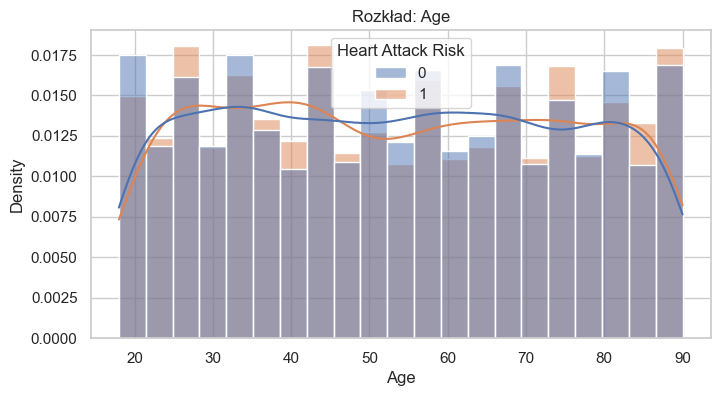

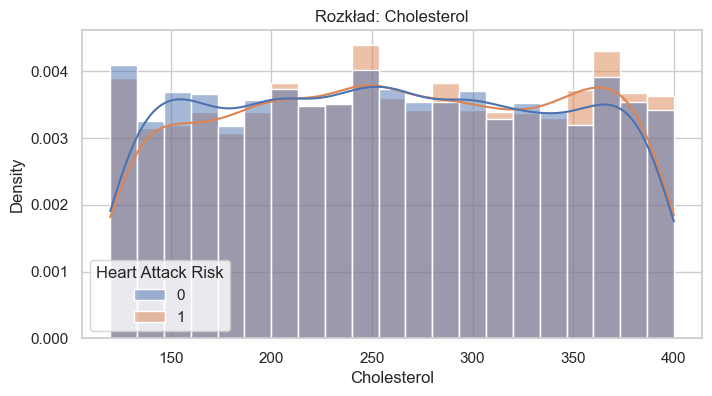

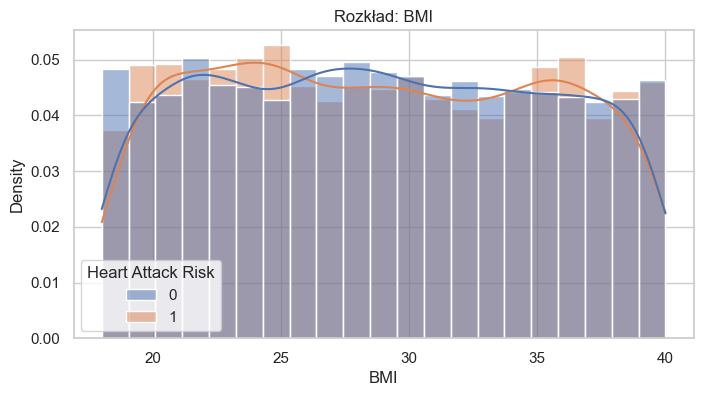

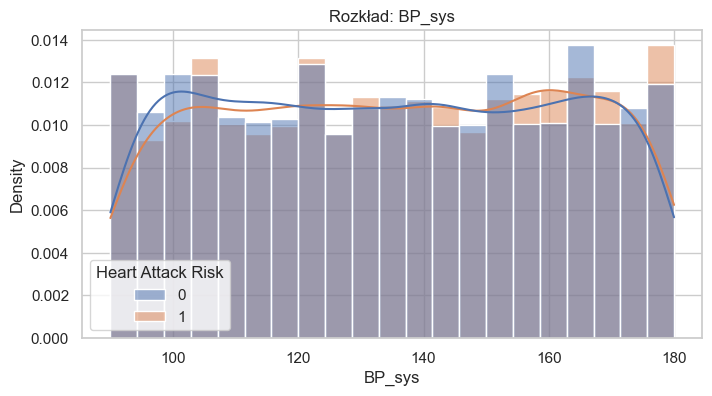

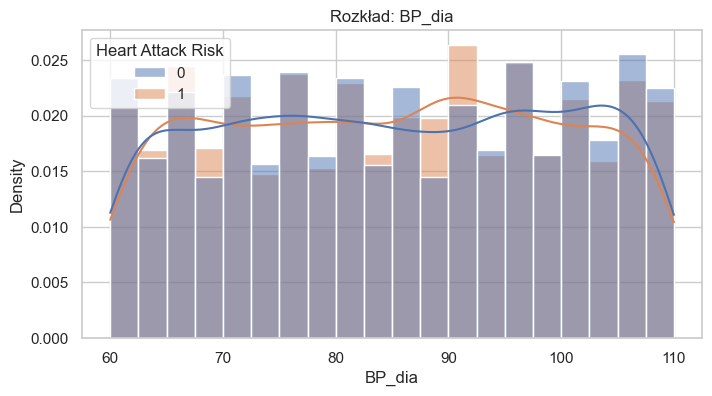

In [ ]:
for col in ["Age", "Cholesterol", "BMI", "BP_sys", "BP_dia"]:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, hue="Heart Attack Risk", kde=True, stat="density", common_norm=False)
    plt.title(f"Rozkład: {col}")
    plt.show()

## Korelacje

Heart Attack Risk                  1.000000
Cholesterol                        0.019340
BP_sys                             0.018585
Diabetes                           0.017225
Exercise Hours Per Week            0.011133
Triglycerides                      0.010471
Income                             0.009628
Age                                0.006403
Medication Use                     0.002234
Previous Heart Problems            0.000274
BMI                                0.000020
Family History                    -0.001652
Smoking                           -0.004051
Stress Level                      -0.004111
Heart Rate                        -0.004251
Physical Activity Days Per Week   -0.005014
Sedentary Hours Per Day           -0.005613
BP_dia                            -0.007509
Obesity                           -0.013318
Alcohol Consumption               -0.013778
Sleep Hours Per Day               -0.018528
Name: Heart Attack Risk, dtype: float64

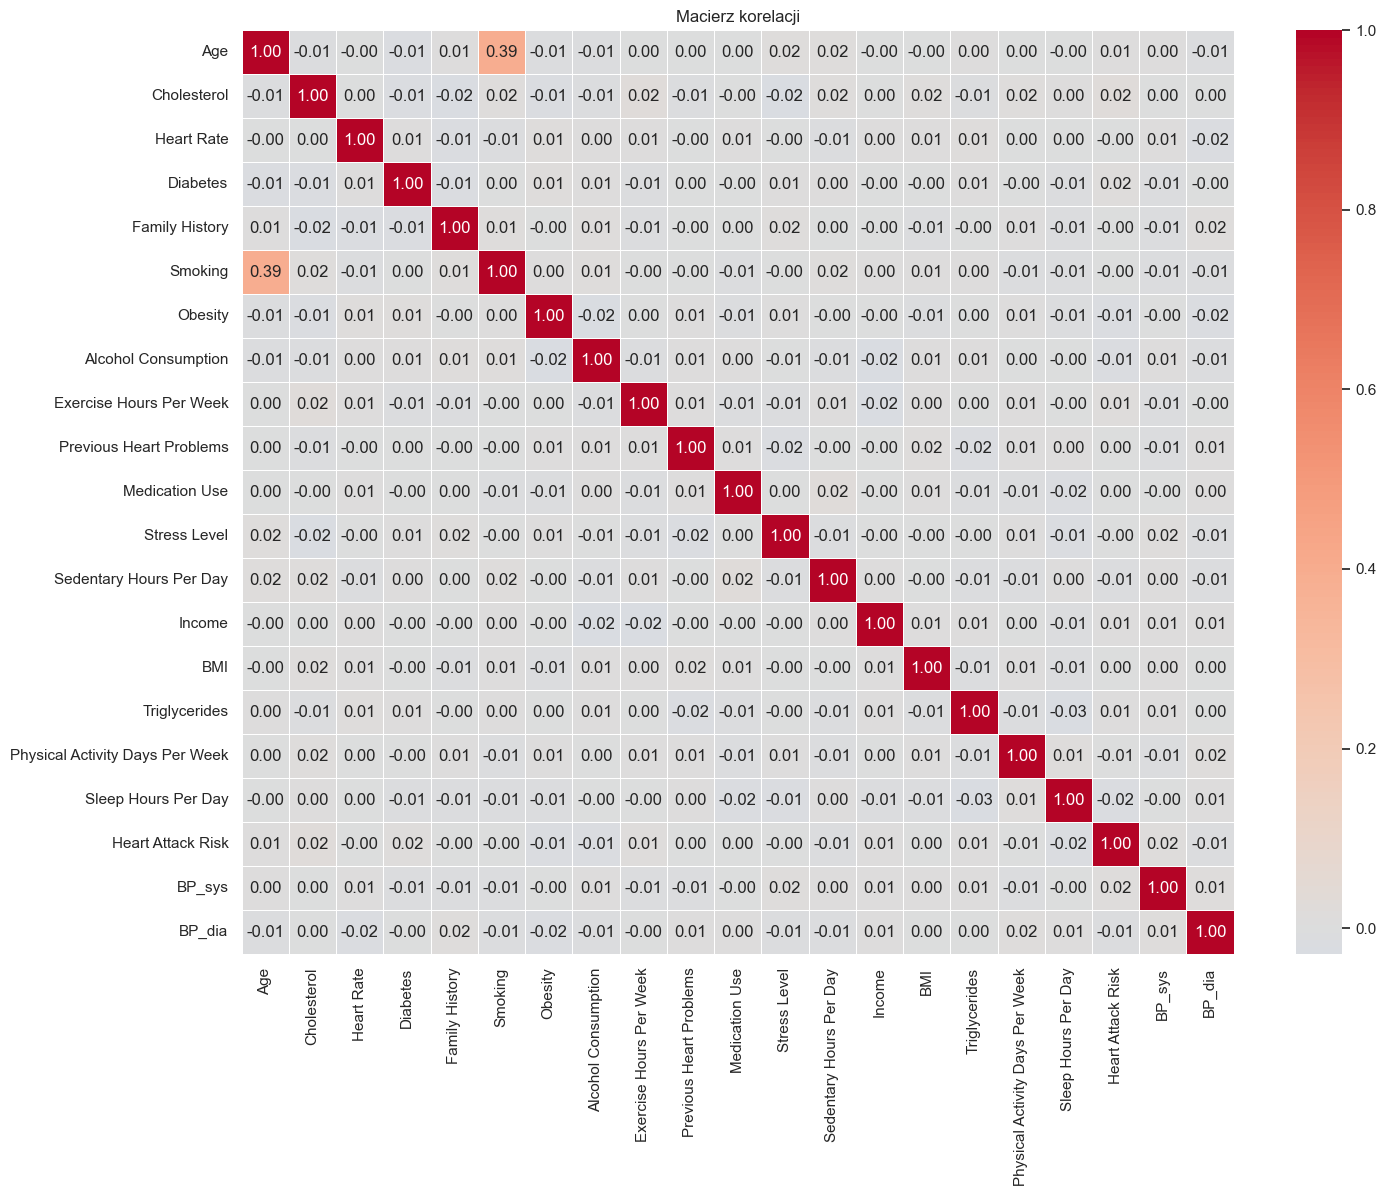

In [29]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

display(corr["Heart Attack Risk"].sort_values(ascending=False))

plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Macierz korelacji")
plt.show()

## Hipoteza badawcza
Nasza grupa postawiła hipotezę, iż zastosowanie algorytmów uczenia maszynowego pozwoli na skuteczną predykcję ryzyka zawału serca u pacjentów na podstawie ich danych klinicznych i behawioralnych. Zakładamy, że najważniejszymi predykatorami (cechami o najwyższej wadze decyzyjnej dla modelu) będą podwyższone ciśnienie krwi, wysoki poziom cholesterolu, wiek oraz styl życia (dieta i palenie).

## Krótki stan wiedzy
W literaturze dotyczącej predykcji chorób serca najczęściej stosuje się klasyczne modele uczenia maszynowego, takie jak regresja logistyczna, SVM, Random Forest, KNN oraz metody boostingowe. Przeglądy i badania porównawcze pokazują, że modele zespołowe zwykle osiągają bardzo dobre wyniki na danych tabelarycznych, ponieważ dobrze radzą sobie z zależnościami nieliniowymi i interakcjami między cechami.

W nowszych publikacjach podkreśla się, że Random Forest i XGBoost często przewyższają prostsze modele, ale jednocześnie zwraca się uwagę na potrzebę lepszej interpretowalności, walidacji zewnętrznej i używania większych, bardziej reprezentatywnych zbiorów danych. Oznacza to, że samo uzyskanie wysokiej dokładności nie wystarcza — ważne jest także zrozumienie działania modelu i możliwość jego praktycznego wykorzystania.

# Analiza potencjalnych kandydatów na model

W celu rozwiązania problemu przewidywania ryzyka zawału serca przeanalizowano cztery modele uczenia maszynowego. Oceniono ich sposób działania, zalety, wady oraz dopasowanie do charakterystyki zbioru danych.



## 1. Regresja Logistyczna (Logistic Regression)
**Status:** Model wybrany do implementacji

### Sposób działania
Regresja logistyczna jest modelem klasyfikacji binarnej. Algorytm oblicza liniową kombinację cech wejściowych, a następnie przekształca wynik za pomocą funkcji sigmoidalnej, która zwraca wartość z przedziału od 0 do 1. Otrzymana wartość interpretowana jest jako prawdopodobieństwo przynależności do klasy pozytywnej, czyli wystąpienia zawału serca.

### Zalety
* Szybkie trenowanie i predykcja.
* Łatwa interpretacja wyników.
* Możliwość określenia wpływu poszczególnych cech na ryzyko choroby.
* Niewielka podatność na przeuczenie przy zastosowaniu regularyzacji.

### Wady
* Zakłada liniową zależność pomiędzy cechami a wynikiem.
* Słabo radzi sobie ze złożonymi zależnościami nieliniowymi.
* Wymaga odpowiedniego przygotowania danych.

### Dopasowanie do problemu i danych
Model dobrze sprawdza się jako punkt odniesienia (baseline) dla problemów medycznych. W analizowanym zbiorze występują cechy takie jak wiek, ciśnienie krwi czy poziom cholesterolu, które często wykazują bezpośredni związek z ryzykiem chorób serca.

---

## 2. Drzewo Decyzyjne (Decision Tree)
**Status:** Model wybrany do implementacji

### Sposób działania
Drzewo decyzyjne dzieli dane na kolejne podzbiory na podstawie wartości cech. W każdym węźle wybierana jest cecha najlepiej rozdzielająca obserwacje na klasy, np. według wskaźnika Giniego lub entropii. Proces ten jest powtarzany aż do osiągnięcia liści reprezentujących końcową decyzję klasyfikacyjną.

### Zalety
* Łatwa interpretacja i wizualizacja.
* Brak konieczności skalowania danych.
* Możliwość wykrywania zależności nieliniowych.
* Automatyczne uwzględnianie interakcji pomiędzy cechami.

### Wady
* Duża podatność na przeuczenie.
* Niestabilność modelu przy niewielkich zmianach danych.
* Często niższa dokładność niż metody zespołowe.

### Dopasowanie do problemu i danych
Model jest dobrze dopasowany do problemu medycznego, ponieważ proces podejmowania decyzji przypomina schematy diagnostyczne stosowane przez lekarzy. Pozwala również wykrywać zależności między wieloma czynnikami ryzyka.

---

## 3. Las Losowy (Random Forest)

### Sposób działania
Las losowy jest metodą zespołową składającą się z wielu drzew decyzyjnych. Każde drzewo trenowane jest na losowym podzbiorze danych i losowym zestawie cech. Końcowa decyzja podejmowana jest poprzez głosowanie większościowe wszystkich drzew.

### Zalety
* Wysoka dokładność klasyfikacji.
* Mniejsza podatność na przeuczenie niż pojedyncze drzewo.
* Dobra odporność na szum w danych.
* Możliwość określenia ważności cech.

### Wady
* Mniejsza interpretowalność.
* Większe wymagania obliczeniowe.
* Trudniejsza wizualizacja procesu podejmowania decyzji.

### Dopasowanie do problemu i danych
Model dobrze radzi sobie z danymi medycznymi zawierającymi wiele zmiennych opisujących stan zdrowia pacjenta. Może osiągać lepsze wyniki predykcyjne niż pojedyncze drzewo decyzyjne.

---

## 4. Maszyna Wektorów Nośnych (Support Vector Machine – SVM)

### Sposób działania
SVM poszukuje hiperpłaszczyzny, która najlepiej rozdziela obserwacje należące do różnych klas. Algorytm maksymalizuje margines pomiędzy klasami, a dzięki zastosowaniu funkcji jądrowych (kernel) może modelować również zależności nieliniowe.

### Zalety
* Wysoka skuteczność klasyfikacji.
* Dobra praca w przestrzeniach wielowymiarowych.
* Stosunkowo duża odporność na przeuczenie.

### Wady
* Konieczność skalowania danych.
* Trudny dobór parametrów modelu.
* Ograniczona interpretowalność wyników.
* Większy koszt obliczeniowy dla dużych zbiorów danych.

### Dopasowanie do problemu i danych
SVM może być skuteczny w przypadku występowania złożonych zależności pomiędzy cechami zdrowotnymi pacjenta. Stanowi wartościowy model porównawczy dla regresji logistycznej i drzewa decyzyjnego.

---

## Podsumowanie porównawcze

| Model | Główne zalety | Główne wady | Dopasowanie do danych medycznych |
|---|---|---|---|
| **Regresja Logistyczna** | Szybkość, łatwa interpretacja. | Problem z nieliniowością. | Doskonały model bazowy (baseline). |
| **Drzewo Decyzyjne** | Wizualizacja ścieżki decyzyjnej. | Podatność na przeuczenie. | Zgodność ze schematami diagnostycznymi lekarzy. |
| **Las Losowy** | Wysoka precyzja, odporność na szum. | Słabsza interpretowalność. | Dobrze radzi sobie z wieloma zmiennymi. |
| **SVM** | Skuteczność w wielu wymiarach. | Skomplikowany dobór parametrów. | Wychwytuje złożone zależności nieliniowe. |